# GraphRAG Query Engine — Evaluation Notebook

Evaluates the Personalised PageRank–based GraphRAG pipeline on the Marie Curie knowledge graph.

**Sections:**
1. Build Knowledge Graph
2. Run Query Engine (pretty-printed response)
3. Retrieval Metrics (MRR, Hit@k, Precision, Recall)
4. Score Decay by Hop Distance
5. Ranked Entity Table

In [7]:
%matplotlib inline

import sys
from pathlib import Path

# Make sure project root is on the path
ROOT = Path().resolve().parents[1]
sys.path.insert(0, str(ROOT))

from src.graphrag import KnowledgeGraph, GraphRAGQueryEngine
from src.graphrag.pagerank_retrieval import PageRankRetrieval
from src.metrics import GraphRAGMetrics

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

# GS palette
GS_NAVY = '#003366'
GS_GOLD = '#C9A84C'
GS_PALE = '#EBF2FA'

mpl.rcParams.update({
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.prop_cycle':   mpl.cycler(color=[GS_NAVY, GS_GOLD]),
    'figure.facecolor':  'white',
})

## 1. Build Knowledge Graph

In [8]:
kg = KnowledgeGraph()
kg.add_triples([
    ("Marie Curie", "is_a", "physicist"),
    ("Marie Curie", "is_a", "chemist"),
    ("Marie Curie", "discovered", "polonium"),
    ("Marie Curie", "discovered", "radium"),
    ("Marie Curie", "coined_term", "radioactivity"),
    ("Marie Curie", "developed", "mobile_xray_unit"),
    ("Marie Curie", "awarded", "Nobel_Prize_Physics_1903"),
    ("Marie Curie", "awarded", "Nobel_Prize_Chemistry_1911"),
    ("Pierre Curie", "co_discovered", "polonium"),
    ("Pierre Curie", "co_discovered", "radium"),
    ("Pierre Curie", "married", "Marie Curie"),
    ("radium", "is_a", "radioactive_element"),
    ("radium", "emits", "alpha_radiation"),
    ("radium", "emits", "gamma_radiation"),
    ("radium", "property_of", "radioactivity"),
    ("radioactivity", "enables", "radiation_therapy"),
    ("radium", "used_in", "radium_therapy"),
    ("radium_therapy", "is_a_form_of", "radiation_therapy"),
    ("radiation_therapy", "treats", "cancer"),
    ("radiation_therapy", "led_to", "radiotherapy"),
    ("mobile_xray_unit", "is_a", "X-ray_device"),
    ("X-ray_device", "enables", "X-ray_imaging"),
    ("X-ray_imaging", "is_a_form_of", "medical_imaging"),
    ("X-ray_imaging", "led_to", "CT_scan"),
    ("CT_scan", "is_a_form_of", "medical_imaging"),
    ("radium", "inspired", "nuclear_medicine"),
    ("nuclear_medicine", "uses", "radioactive_tracers"),
    ("radioactive_tracers", "enable", "PET_scan"),
    ("PET_scan", "is_a_form_of", "medical_imaging"),
    ("radium", "led_to_study_of", "isotopes"),
    ("isotopes", "used_in", "radioactive_tracers"),
    ("isotopes", "used_in", "MRI_contrast_agents"),
    ("MRI_contrast_agents", "enhance", "MRI_scan"),
    ("MRI_scan", "is_a_form_of", "medical_imaging"),
    ("medical_imaging", "includes", "CT_scan"),
    ("medical_imaging", "includes", "MRI_scan"),
    ("medical_imaging", "includes", "PET_scan"),
    ("medical_imaging", "includes", "X-ray_imaging"),
    ("medical_imaging", "advances", "cancer_diagnosis"),
    ("medical_imaging", "advances", "neurology"),
    ("radiotherapy", "is_a_form_of", "medical_imaging"),
    ("radiotherapy", "uses", "gamma_radiation"),
    ("gamma_radiation", "emitted_by", "radium"),
    ("Nobel_Prize_Physics_1903", "recognises", "radioactivity"),
    ("radioactivity", "foundation_of", "nuclear_physics"),
    ("nuclear_physics", "enables", "nuclear_medicine"),
    ("nuclear_medicine", "is_a_form_of", "medical_imaging"),
])

print(f"Entities : {kg.n_entities}")
print(f"Relations: {kg.n_relations}")

Entities : 30
Relations: 47


## 2. Run Query Engine

In [9]:
engine = GraphRAGQueryEngine(kg, p=0.15, k=15)
seeds  = ["Marie Curie", "medical_imaging"]

resp = engine.query(
    "What discoveries by Marie Curie led to later advances in medical imaging?",
    seed_entities=seeds,
    k=15,
)

print(resp.pretty_print())

Query   : What discoveries by Marie Curie led to later advances in medical imaging?
Seeds   : Marie Curie, medical_imaging

Top Entities (PageRank-ranked):
----------------------------------------
  #01  medical_imaging                      score=0.270344  hop=0
  #02  Marie Curie                          score=0.081317  hop=0
  #03  CT_scan                              score=0.067532  hop=1
  #04  PET_scan                             score=0.058588  hop=1
  #05  X-ray_imaging                        score=0.057203  hop=1
  #06  MRI_scan                             score=0.050386  hop=1
  #07  cancer_diagnosis                     score=0.043221  hop=1
  #08  neurology                            score=0.043221  hop=1
  #09  radioactivity                        score=0.028421  hop=1
  #10  radium                               score=0.027438  hop=1
  #11  radiation_therapy                    score=0.024017  hop=2
  #12  nuclear_medicine                     score=0.022705  hop=2
  #13  radi

## 3. Retrieval Metrics (Section 8.4)

In [10]:
retrieval = PageRankRetrieval(kg, p=0.15)
results   = retrieval.retrieve(seeds, k=30)

relevant = {
    "radium", "radioactivity", "radiation_therapy", "radiotherapy",
    "X-ray_imaging", "CT_scan", "PET_scan", "MRI_scan",
    "nuclear_medicine", "medical_imaging", "isotopes",
    "mobile_xray_unit", "radioactive_tracers",
}

metrics = GraphRAGMetrics(results=results, relevant_entities=relevant, seeds=seeds).compute()

import pandas as pd
pd.set_option('display.float_format', '{:.4f}'.format)
pd.DataFrame([metrics.as_dict()]).T.rename(columns={0: 'Value'})

,Value
MRR,1.0000
Hit@1,1.0000
Hit@3,1.0000
Hit@5,1.0000
Hit@10,1.0000
Mean Hop Distance (top-10),0.8000
Personalisation Fidelity ρ,0.5042
Seed/Non-Seed Score Ratio,7.5936
Precision@1,1.0000
Precision@3,0.6667


## 4. Score Decay by Hop Distance

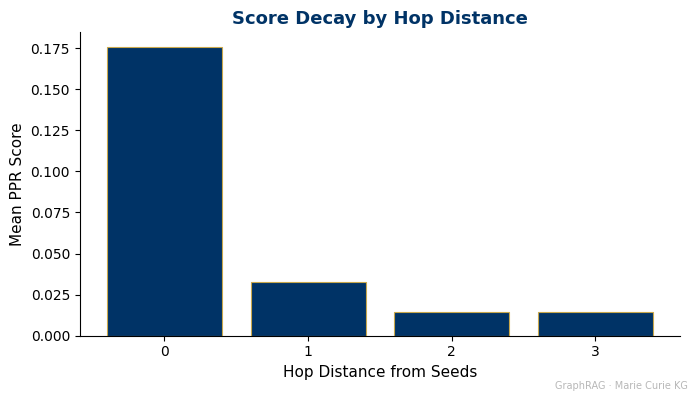

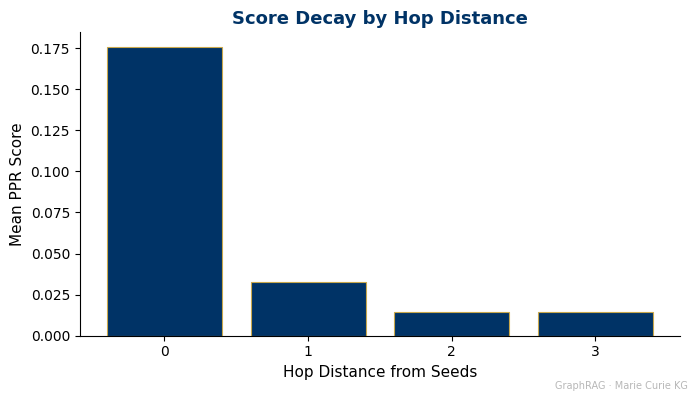

In [11]:
from IPython.display import display as ipy_display

hops   = sorted(metrics.score_by_hop.keys())
scores = [metrics.score_by_hop[h] for h in hops]

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(hops, scores, color=GS_NAVY, edgecolor=GS_GOLD, linewidth=0.8)
ax.set_xlabel('Hop Distance from Seeds', fontsize=11)
ax.set_ylabel('Mean PPR Score', fontsize=11)
ax.set_title('Score Decay by Hop Distance', fontsize=13, color=GS_NAVY, fontweight='bold')
ax.set_xticks(hops)
fig.text(0.99, 0.01, 'GraphRAG · Marie Curie KG', ha='right', va='bottom',
         fontsize=7, color='#888888', alpha=0.6)
plt.tight_layout()
ipy_display(fig)
plt.close(fig)

## 5. Ranked Entity Table

In [12]:
rows = []
for r in results:
    rows.append({
        'Rank':        r.rank,
        'Entity':      r.entity_name,
        'PPR Score':   round(r.score, 6),
        'Hop':         r.hop_distance,
        'Relevant':    '✓' if r.entity_name in relevant else '',
        'Seed':        '✓' if r.entity_name in set(seeds) else '',
    })

pd.DataFrame(rows).set_index('Rank')

,Entity,PPR Score,Hop,Relevant,Seed
Rank,,,,,
1,medical_imaging,0.2703,0.0000,✓,✓
2,Marie Curie,0.0813,0.0000,,✓
3,CT_scan,0.0675,1.0000,✓,
4,PET_scan,0.0586,1.0000,✓,
5,X-ray_imaging,0.0572,1.0000,✓,
6,MRI_scan,0.0504,1.0000,✓,
7,cancer_diagnosis,0.0432,1.0000,,
8,neurology,0.0432,1.0000,,
9,radioactivity,0.0284,1.0000,✓,
